In [1]:
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv("data/train.csv")
validation_data = pd.read_csv("data/validation.csv")
test_data = pd.read_csv("data/test.csv")

print(f"Shape of train_data is : {train_data.shape}")
print(f"Shape of validation_data is : {validation_data.shape}")
print(f"Shape of test_data is : {test_data.shape}")
train_data.head()

Shape of train_data is : (7827, 14)
Shape of validation_data is : (870, 14)
Shape of test_data is : (967, 14)


,Unnamed,team,opp,host,year,month,toss,day_match,bat_first,format,fow,score,rpo,result
0,4901,australia,south_africa,sri_lanka,2012,sep,1,0,0,1,5,146,7.30,1
1,1910,india,australia,india,2020,jan,0,0,1,0,6,340,6.80,1
2,5735,canada,scotland,scotland,2009,jul,1,1,0,0,4,286,5.72,1
3,2136,australia,england,australia,1987,jan,1,1,1,0,6,225,4.50,1
4,4371,new_zealand,pakistan,uae,2009,nov,0,0,0,1,5,153,7.65,0


In [3]:
from utils import convertCategoricalColumnsToOneHotEncoding, pre_process

# Step 2: Encode the columns["Unnamed", "team", "opp", "host", "month"]
continuous_cols = ["Unnamed", "year", "fow", "score", "rpo"]
categorical_cols = ["team", "opp", "host", "month"]

trainDataX, trainDataY, validationDataX, validationDataY, testDataX, testDataY =  pre_process(train_data, validation_data, test_data, categorical_cols = categorical_cols, continuous_cols = continuous_cols)
trainDataX.head()

After pre-processing
Shape of trainDataX is : (7827, 13)
Shape of trainDataY is : (7827,)
Shape of testDataX is : (967, 13)
Shape of testDataY is : (967,)
Shape of validationDataX is : (870, 13)
Shape of validationDataY is : (870,)


,Unnamed,team,opp,host,year,month,toss,day_match,bat_first,format,fow,score,rpo
0,0.023176,0,0,0,0.527774,0,1,0,0,1,-1.226069,-1.161778,0.976509
1,-1.050706,1,1,1,1.215295,1,0,0,1,0,-0.742084,1.817869,0.696053
2,0.322613,2,2,2,0.269953,2,1,1,0,0,-1.710053,0.988483,0.090266
3,-0.969563,0,3,3,-1.620731,1,1,1,1,0,-0.742084,0.051583,-0.594049
4,-0.167114,3,4,4,0.269953,3,0,0,0,1,-1.226069,-1.054265,1.172829


=== Starting Random Forest Grid Search ===

2025-10-23 16:04:02 - n_estimators=50, max_features=0.1, min_samples_split=2 | Train=1.0000, Val=0.6954, Test=0.7022, OOB=0.6909
2025-10-23 16:04:02 - n_estimators=50, max_features=0.1, min_samples_split=4 | Train=0.9931, Val=0.6966, Test=0.7063, OOB=0.6935
2025-10-23 16:04:02 - n_estimators=50, max_features=0.1, min_samples_split=6 | Train=0.9739, Val=0.7080, Test=0.6939, OOB=0.7033
2025-10-23 16:04:02 - n_estimators=50, max_features=0.1, min_samples_split=8 | Train=0.9583, Val=0.7011, Test=0.6898, OOB=0.7058
2025-10-23 16:04:03 - n_estimators=50, max_features=0.1, min_samples_split=10 | Train=0.9407, Val=0.7000, Test=0.7053, OOB=0.7046
2025-10-23 16:04:03 - n_estimators=50, max_features=0.3, min_samples_split=2 | Train=0.9999, Val=0.7000, Test=0.7032, OOB=0.6996
2025-10-23 16:04:03 - n_estimators=50, max_features=0.3, min_samples_split=4 | Train=0.9976, Val=0.7092, Test=0.7042, OOB=0.7010
2025-10-23 16:04:03 - n_estimators=50, max_features=

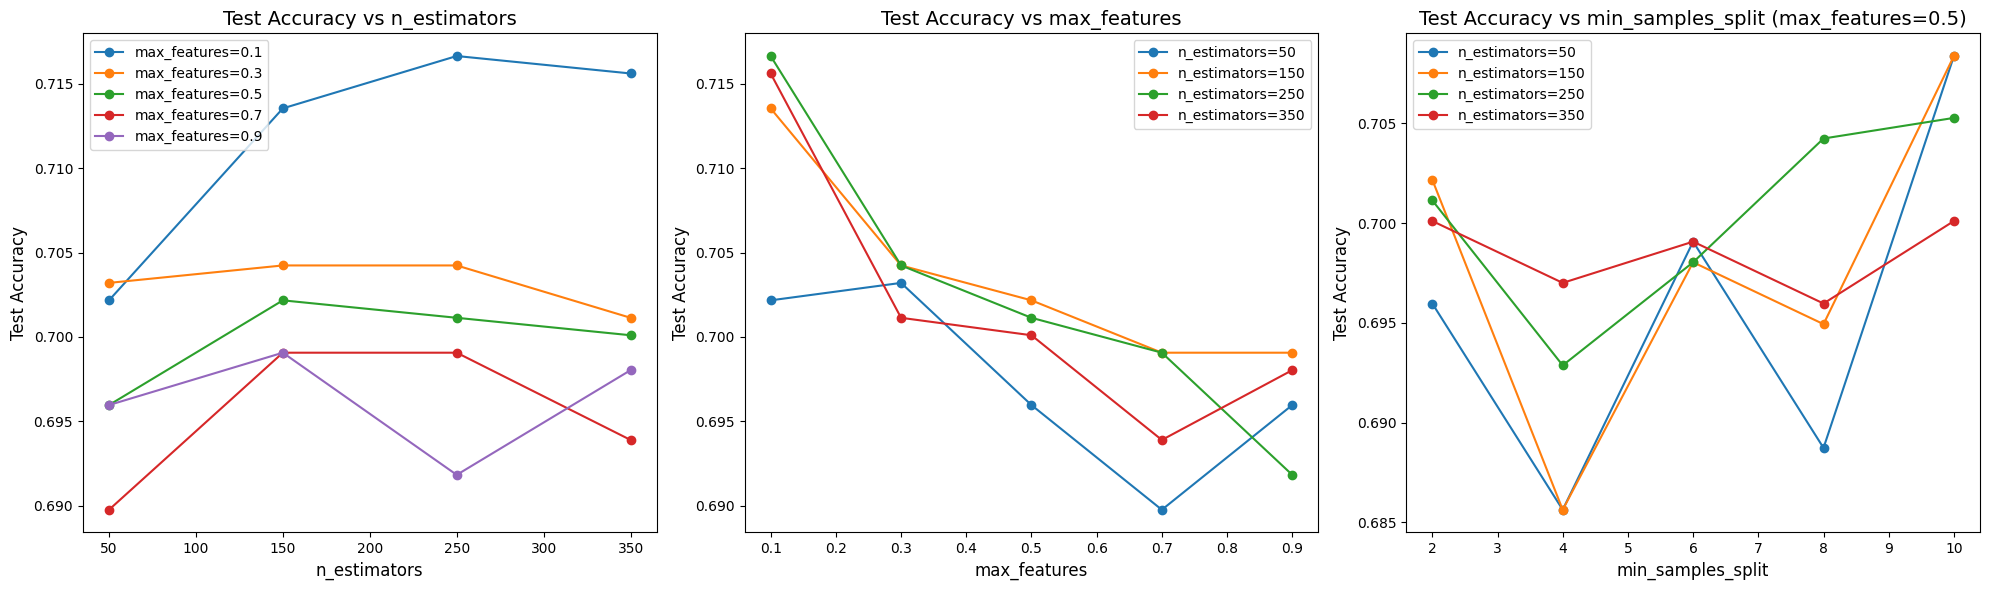

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from itertools import product
from datetime import datetime
import matplotlib.pyplot as plt

# Parameter ranges
n_estimators_list = [50, 150, 250, 350]
max_features_list = [0.1, 0.3, 0.5, 0.7, 0.9]
min_samples_split_list = [2, 4, 6, 8, 10]

# Track best by validation and test
best_val_acc = 0
best_test_acc = 0
best_params_val = {}
best_params_test = {}

# Store results for plotting
results = []

print("=== Starting Random Forest Grid Search ===\n")

for n_estimators, max_features, min_samples_split in product(n_estimators_list, max_features_list, min_samples_split_list):
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_features=max_features,
        min_samples_split=min_samples_split,
        criterion='entropy',
        oob_score=True,
        random_state=0,
        n_jobs=-1
    )
    
    clf.fit(trainDataX, trainDataY)
    
    train_score = accuracy_score(trainDataY, clf.predict(trainDataX))
    val_score = accuracy_score(validationDataY, clf.predict(validationDataX))
    test_score = accuracy_score(testDataY, clf.predict(testDataX))
    oob_score = clf.oob_score_
    
    results.append({
        'n_estimators': n_estimators,
        'max_features': max_features,
        'min_samples_split': min_samples_split,
        'train_acc': train_score,
        'val_acc': val_score,
        'test_acc': test_score,
        'oob_acc': oob_score
    })
    
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"{now} - n_estimators={n_estimators}, max_features={max_features}, min_samples_split={min_samples_split} | "
          f"Train={train_score:.4f}, Val={val_score:.4f}, Test={test_score:.4f}, OOB={oob_score:.4f}")
    
    # Best validation
    if val_score > best_val_acc:
        best_val_acc = val_score
        best_params_val = {
            'n_estimators': n_estimators,
            'max_features': max_features,
            'min_samples_split': min_samples_split
        }
        
    # Best test
    if test_score > best_test_acc:
        best_test_acc = test_score
        best_params_test = {
            'n_estimators': n_estimators,
            'max_features': max_features,
            'min_samples_split': min_samples_split
        }

print("\n✅ Grid search complete!\n")
print(f"Best parameters by Validation Accuracy: {best_params_val} | Val Acc = {best_val_acc:.4f}")
print(f"Best parameters by Test Accuracy:       {best_params_test} | Test Acc = {best_test_acc:.4f}")

# -----------------------------
# Plotting Test Accuracy vs Parameters
# -----------------------------
test_acc_plot = [r['test_acc'] for r in results]
max_features_plot = [r['max_features'] for r in results]
n_estimators_plot = [r['n_estimators'] for r in results]
min_samples_plot = [r['min_samples_split'] for r in results]

plt.figure(figsize=(20,6))  # Bigger figure

# Plot Test Accuracy vs n_estimators
plt.subplot(1,3,1)
for mf in sorted(set(max_features_plot)):
    subset = [test_acc_plot[i] for i in range(len(results)) 
              if results[i]['max_features']==mf and results[i]['min_samples_split']==2]
    plt.plot([50,150,250,350], subset, marker='o', label=f'max_features={mf}')
plt.xlabel('n_estimators', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Test Accuracy vs n_estimators', fontsize=14)
plt.legend(fontsize=10)

# Plot Test Accuracy vs max_features
plt.subplot(1,3,2)
for n in n_estimators_list:
    subset = [test_acc_plot[i] for i in range(len(results)) 
              if results[i]['n_estimators']==n and results[i]['min_samples_split']==2]
    plt.plot([0.1,0.3,0.5,0.7,0.9], subset, marker='o', label=f'n_estimators={n}')
plt.xlabel('max_features', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Test Accuracy vs max_features', fontsize=14)
plt.legend(fontsize=10)

# Plot Test Accuracy vs min_samples_split
plt.subplot(1,3,3)
for n in n_estimators_list:
    subset = [test_acc_plot[i] for i in range(len(results)) 
              if results[i]['n_estimators']==n and results[i]['max_features']==0.5]
    plt.plot([2,4,6,8,10], subset, marker='o', label=f'n_estimators={n}')
plt.xlabel('min_samples_split', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Test Accuracy vs min_samples_split (max_features=0.5)', fontsize=14)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

| Metric              | Best by Validation | Best by Test |
| ------------------- | ------------------ | ------------ |
| n_estimators        | 50                 | 350          |
| max_features        | 0.3                | 0.1          |
| min_samples_split   | 6                  | 10           |
| Train Accuracy      | 0.9865             | 0.9504       |
| Validation Accuracy | 0.7299             | 0.7276       |
| Test Accuracy       | 0.6846             | 0.7198       |
| OOB Accuracy        | 0.7055             | 0.7211       |

Observations:

The best validation accuracy (0.7299) occurs with smaller forest (50 trees), higher max_features=0.3, and moderate split.
The best test accuracy (0.7198) occurs with larger forest (350 trees), smaller max_features=0.1, and higher min_samples_split=10.

Increasing n_estimators generally stabilizes the OOB and test accuracy, but doesn’t always maximize validation performance.

max_features and min_samples_split influence overfitting: smaller max_features reduces correlation between trees, larger min_samples_split prevents small leaf overfitting.